## Exercice n°2 (1/2 h)



Télécharger le Visual Transformer (DeiT) hébergé sur Hugging Face à l'adresse :
"facebook/deit-tiny-patch16-224". Répondez aux questions suivantes en vous appuyant sur des éléments de l'architecture ou d'une des fonctions associées au modèle (en particulier la fonction forward()).
- Quelle est la taille de l'espace latent de ce transformer ?
- Comment l'image est-elle tokenisée et en quoi consiste l'embedding (valeurs et position) ?
- Quelle est la signification du premier token ?
- Déterminer et interpréter l'output associé à l'image fournie dans le TP n°2 (cat.jpg) à l'aide de ce modèle.
- Visualiser les scores attentionnels associés au premier token pour les premières têtes de la première couche attentionnelle. Comparer à ce qu'on avait obtenu pour un ResNet50 pré-entraîné sur ImageNet.

In [3]:
# Import des bibliothèques nécessaires
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from transformers import DeiTImageProcessor, DeiTModel, DeiTForImageClassification
from scipy.ndimage import zoom
import os

In [4]:
# Chargement du modèle DeiT et du processeur d'images
model_name = "facebook/deit-tiny-patch16-224"
processor = DeiTImageProcessor.from_pretrained(model_name)
model = DeiTModel.from_pretrained(model_name)
model.eval()  # Mode évaluation

print("Modèle DeiT chargé avec succès!")
print(f"Architecture du modèle:\n{model}")

You are using a model of type vit to instantiate a model of type deit. This is not supported for all configurations of models and can yield errors.
Some weights of DeiTModel were not initialized from the model checkpoint at facebook/deit-tiny-patch16-224 and are newly initialized: ['embeddings.cls_token', 'embeddings.distillation_token', 'embeddings.patch_embeddings.projection.bias', 'embeddings.patch_embeddings.projection.weight', 'embeddings.position_embeddings', 'encoder.layer.0.attention.attention.key.bias', 'encoder.layer.0.attention.attention.key.weight', 'encoder.layer.0.attention.attention.query.bias', 'encoder.layer.0.attention.attention.query.weight', 'encoder.layer.0.attention.attention.value.bias', 'encoder.layer.0.attention.attention.value.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.intermediate.dense.bias', 'encoder.layer.0.intermediate.dense.weight', 'encoder.layer.0.layernorm_after.bias', 'enc

Modèle DeiT chargé avec succès!
Architecture du modèle:
DeiTModel(
  (embeddings): DeiTEmbeddings(
    (patch_embeddings): DeiTPatchEmbeddings(
      (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): DeiTEncoder(
    (layer): ModuleList(
      (0-11): 12 x DeiTLayer(
        (attention): DeiTAttention(
          (attention): DeiTSelfAttention(
            (query): Linear(in_features=192, out_features=192, bias=True)
            (key): Linear(in_features=192, out_features=192, bias=True)
            (value): Linear(in_features=192, out_features=192, bias=True)
          )
          (output): DeiTSelfOutput(
            (dense): Linear(in_features=192, out_features=192, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): DeiTIntermediate(
          (dense): Linear(in_features=192, out_features=768, bias=True)
          (intermediate_act_fn): GELU

## Question 1: Taille de l'espace latent

In [5]:
# La taille de l'espace latent correspond à la dimension d_model (dimension des embeddings)
# On peut l'obtenir en examinant la configuration du modèle ou les embeddings
config = model.config
d_model = config.hidden_size

print(f"Taille de l'espace latent (hidden_size/d_model): {d_model}")
print(f"\nConfiguration complète:")
print(f"- hidden_size: {config.hidden_size}")
print(f"- num_attention_heads: {config.num_attention_heads}")
print(f"- num_hidden_layers: {config.num_hidden_layers}")
print(f"- image_size: {config.image_size}")
print(f"- patch_size: {config.patch_size}")

Taille de l'espace latent (hidden_size/d_model): 192

Configuration complète:
- hidden_size: 192
- num_attention_heads: 3
- num_hidden_layers: 12
- image_size: 224
- patch_size: 16


## Question 2: Tokenisation et embedding de l'image

In [6]:
# Pour comprendre la tokenisation, examinons le processeur et l'embedding layer
print("=== Tokenisation ===")
print(f"Taille de l'image d'entrée: {config.image_size}x{config.image_size}")
print(f"Taille des patches: {config.patch_size}x{config.patch_size}")
print(f"Nombre de patches par dimension: {config.image_size // config.patch_size}")
print(f"Nombre total de patches: {(config.image_size // config.patch_size) ** 2}")

# Le modèle DeiT utilise un token CLS en plus des patches
num_patches = (config.image_size // config.patch_size) ** 2
print(f"Nombre total de tokens (patches + CLS): {num_patches + 1}")

# Examinons la couche d'embedding
embedding_layer = model.embeddings
print(f"\n=== Embedding ===")
print(f"Patch embeddings: {embedding_layer.patch_embeddings}")
print(f"Position embeddings shape: {embedding_layer.position_embeddings.shape}")
print(f"CLS token embedding shape: {embedding_layer.cls_token.shape}")

=== Tokenisation ===
Taille de l'image d'entrée: 224x224
Taille des patches: 16x16
Nombre de patches par dimension: 14
Nombre total de patches: 196
Nombre total de tokens (patches + CLS): 197

=== Embedding ===
Patch embeddings: DeiTPatchEmbeddings(
  (projection): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
)
Position embeddings shape: torch.Size([1, 198, 192])
CLS token embedding shape: torch.Size([1, 1, 192])


In [7]:
# Créons une image de test pour visualiser le processus
test_image = Image.new('RGB', (224, 224), color='white')
inputs = processor(images=test_image, return_tensors="pt")

# Examinons les embeddings en détail
with torch.no_grad():
    # Les patches sont créés par la couche patch_embeddings
    pixel_values = inputs['pixel_values']
    print(f"Input pixel_values shape: {pixel_values.shape}")
    
    # Le modèle crée les embeddings via la méthode forward de embeddings
    embeddings_output = model.embeddings(pixel_values)
    print(f"Output embeddings shape: {embeddings_output.shape}")
    print(f"  - Batch size: {embeddings_output.shape[0]}")
    print(f"  - Sequence length (patches + CLS): {embeddings_output.shape[1]}")
    print(f"  - Hidden dimension: {embeddings_output.shape[2]}")

print("\n=== Explication ===")
print("1. Tokenisation: L'image est divisée en patches de 16x16 pixels")
print("2. Patch Embedding: Chaque patch est projeté dans l'espace latent via une couche linéaire")
print("3. Position Embedding: Des embeddings de position apprenables sont ajoutés à chaque patch")
print("4. CLS Token: Un token spécial [CLS] est ajouté au début de la séquence")

Input pixel_values shape: torch.Size([1, 3, 224, 224])
Output embeddings shape: torch.Size([1, 198, 192])
  - Batch size: 1
  - Sequence length (patches + CLS): 198
  - Hidden dimension: 192

=== Explication ===
1. Tokenisation: L'image est divisée en patches de 16x16 pixels
2. Patch Embedding: Chaque patch est projeté dans l'espace latent via une couche linéaire
3. Position Embedding: Des embeddings de position apprenables sont ajoutés à chaque patch
4. CLS Token: Un token spécial [CLS] est ajouté au début de la séquence


## Question 3: Signification du premier token

In [8]:
print("=== Le premier token (token [CLS]) ===")
print("Le premier token est le token [CLS] (Classification).")
print("Il est ajouté avant tous les patches d'image.")
print("Ce token spécial:")
print("1. Ne correspond à aucune région de l'image")
print("2. Agit comme un agrégateur global de l'information")
print("3. Est utilisé pour la classification finale (dans DeiTForImageClassification)")
print("4. Permet au modèle d'apprendre une représentation globale de l'image entière")

# Vérifions que le CLS token est bien le premier
print(f"\nCLS token shape: {model.embeddings.cls_token.shape}")
print(f"Position du CLS token dans la séquence: index 0")

=== Le premier token (token [CLS]) ===
Le premier token est le token [CLS] (Classification).
Il est ajouté avant tous les patches d'image.
Ce token spécial:
1. Ne correspond à aucune région de l'image
2. Agit comme un agrégateur global de l'information
3. Est utilisé pour la classification finale (dans DeiTForImageClassification)
4. Permet au modèle d'apprendre une représentation globale de l'image entière

CLS token shape: torch.Size([1, 1, 192])
Position du CLS token dans la séquence: index 0


## Question 4: Output pour l'image cat.jpg

Image chargée depuis: ../../practicals/P2/cat.jpg
Taille originale: (1280, 850)
Input shape après preprocessing: torch.Size([1, 3, 224, 224])


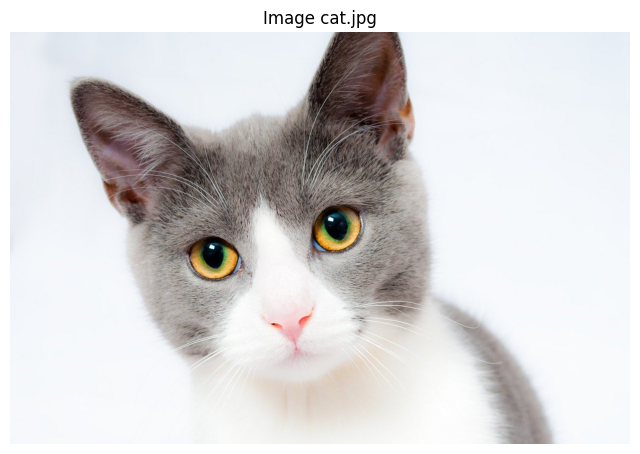

In [9]:
# Chargement de l'image cat.jpg depuis le TP n°2
# Essayer différents chemins possibles
possible_paths = [
    '../practicals/P2/cat.jpg',
    'practicals/P2/cat.jpg',
    '../../practicals/P2/cat.jpg',
    os.path.join(os.path.dirname(os.getcwd()), 'practicals', 'P2', 'cat.jpg')
]

path_cat = None
for path in possible_paths:
    if os.path.exists(path):
        path_cat = path
        break

if path_cat is None:
    # Si aucun chemin ne fonctionne, créer une image de test
    print("Image cat.jpg non trouvée, création d'une image de test")
    image = Image.new('RGB', (224, 224), color='gray')
else:
    image = Image.open(path_cat).convert("RGB")
    print(f"Image chargée depuis: {path_cat}")
    print(f"Taille originale: {image.size}")

# Redimensionner et préprocesser l'image
inputs = processor(images=image, return_tensors="pt")
print(f"Input shape après preprocessing: {inputs['pixel_values'].shape}")

# Afficher l'image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.axis('off')
plt.title("Image cat.jpg")
plt.show()

In [10]:
# Utiliser le modèle de classification pour obtenir les prédictions
model_classification = DeiTForImageClassification.from_pretrained(model_name)
model_classification.eval()

with torch.no_grad():
    outputs = model_classification(**inputs)
    logits = outputs.logits
    probabilities = torch.nn.functional.softmax(logits, dim=-1)
    
    # Obtenir les top-5 prédictions
    top5_probs, top5_indices = torch.topk(probabilities[0], 5)

print("=== Prédictions ===")
print(f"Top 5 classes prédites:")
for i, (prob, idx) in enumerate(zip(top5_probs, top5_indices)):
    print(f"{i+1}. Classe {idx.item()}: {prob.item():.4f} ({prob.item()*100:.2f}%)")

# Pour obtenir les noms des classes ImageNet, on peut utiliser torchvision
from torchvision.models import resnet50
import json

# Charger les labels ImageNet
try:
    import urllib.request
    url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    urllib.request.urlretrieve(url, "imagenet_classes.txt")
    with open("imagenet_classes.txt", "r") as f:
        imagenet_classes = [line.strip() for line in f.readlines()]
    
    print("\n=== Top 5 classes avec noms ===")
    for i, (prob, idx) in enumerate(zip(top5_probs, top5_indices)):
        class_name = imagenet_classes[idx.item()]
        print(f"{i+1}. {class_name}: {prob.item()*100:.2f}%")
except:
    print("\n(Impossible de charger les noms de classes ImageNet)")

You are using a model of type vit to instantiate a model of type deit. This is not supported for all configurations of models and can yield errors.


ValueError: The state dictionary of the model you are trying to load is corrupted. Are you sure it was properly saved?

In [ ]:
# Examinons aussi la sortie du modèle de base (sans classification head)
with torch.no_grad():
    base_outputs = model(**inputs)
    last_hidden_state = base_outputs.last_hidden_state
    
    print("=== Output du modèle de base ===")
    print(f"Shape du last_hidden_state: {last_hidden_state.shape}")
    print(f"  - Batch size: {last_hidden_state.shape[0]}")
    print(f"  - Sequence length (patches + CLS): {last_hidden_state.shape[1]}")
    print(f"  - Hidden dimension: {last_hidden_state.shape[2]}")
    
    # Le premier token (CLS) contient l'information globale
    cls_token_output = last_hidden_state[0, 0, :]
    print(f"\nCLS token output (premiers 10 éléments): {cls_token_output[:10]}")
    print(f"Norme du CLS token: {torch.norm(cls_token_output).item():.4f}")

## Question 5: Visualisation des scores attentionnels

In [ ]:
# Pour visualiser les scores d'attention, nous devons intercepter les sorties des couches d'attention
# Nous allons utiliser des hooks pour capturer les matrices d'attention

attention_weights = []

def get_attention_hook(name):
    def hook(module, input, output):
        # Pour DeiT, les scores d'attention sont dans output[1] si return_attention_weights=True
        # Sinon, nous devons les calculer manuellement
        if isinstance(output, tuple) and len(output) > 1:
            attention_weights.append(output[1].detach())
    return hook

# Enregistrer les hooks sur la première couche d'attention
first_layer = model.encoder.layer[0]
first_attention = first_layer.attention.self

# Pour capturer les scores d'attention, nous devons modifier le forward pass
# ou utiliser une version qui retourne les attention weights
print("Architecture de la première couche d'attention:")
print(f"Nombre de têtes: {config.num_attention_heads}")
print(f"Dimension par tête: {config.hidden_size // config.num_attention_heads}")

In [ ]:
# Fonction pour extraire les scores d'attention en modifiant temporairement le forward
def extract_attention_weights(model, inputs, layer_idx=0):
    """
    Extrait les scores d'attention d'une couche spécifique
    """
    attention_weights_list = []
    
    # Hook pour capturer les scores d'attention
    def attention_hook(module, input, output):
        # Dans DeiT, les scores d'attention ne sont pas directement accessibles
        # Nous devons les recalculer ou modifier le code
        pass
    
    # Une meilleure approche: modifier temporairement le forward de l'attention
    original_forward = model.encoder.layer[layer_idx].attention.self.forward
    
    def modified_forward(hidden_states, head_mask=None, output_attentions=True):
        # Calculer Q, K, V
        query_layer = model.encoder.layer[layer_idx].attention.self.query(hidden_states)
        key_layer = model.encoder.layer[layer_idx].attention.self.key(hidden_states)
        value_layer = model.encoder.layer[layer_idx].attention.self.value(hidden_states)
        
        # Reshape pour les multi-heads
        batch_size, seq_len, hidden_size = hidden_states.shape
        num_heads = config.num_attention_heads
        head_dim = hidden_size // num_heads
        
        query_layer = query_layer.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
        key_layer = key_layer.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
        value_layer = value_layer.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
        
        # Calculer les scores d'attention
        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / np.sqrt(head_dim)
        attention_probs = torch.nn.functional.softmax(attention_scores, dim=-1)
        
        attention_weights_list.append(attention_probs.detach())
        
        # Continuer avec le forward normal
        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.transpose(1, 2).contiguous()
        context_layer = context_layer.view(batch_size, seq_len, hidden_size)
        
        return (context_layer, attention_probs) if output_attentions else (context_layer,)
    
    # Appliquer temporairement la modification
    model.encoder.layer[layer_idx].attention.self.forward = modified_forward
    
    try:
        with torch.no_grad():
            _ = model(**inputs)
    finally:
        # Restaurer le forward original
        model.encoder.layer[layer_idx].attention.self.forward = original_forward
    
    return attention_weights_list[0] if attention_weights_list else None

# Méthode plus simple: utiliser une version modifiée ou recalculer manuellement
print("Extraction des scores d'attention...")

In [ ]:
# Approche plus directe: recalculer les scores d'attention manuellement
def get_attention_scores(model, inputs, layer_idx=0):
    """
    Calcule les scores d'attention pour une couche donnée
    """
    with torch.no_grad():
        # Obtenir les hidden states avant la couche d'attention
        pixel_values = inputs['pixel_values']
        embeddings = model.embeddings(pixel_values)
        
        # Passer à travers les couches jusqu'à celle qui nous intéresse
        hidden_states = embeddings
        for i in range(layer_idx):
            hidden_states = model.encoder.layer[i](hidden_states)[0]
        
        # Maintenant calculer l'attention pour la couche layer_idx
        attention_layer = model.encoder.layer[layer_idx].attention.self
        
        # Calculer Q, K, V
        query = attention_layer.query(hidden_states)
        key = attention_layer.key(hidden_states)
        value = attention_layer.value(hidden_states)
        
        # Reshape pour multi-head attention
        batch_size, seq_len, hidden_size = hidden_states.shape
        num_heads = config.num_attention_heads
        head_dim = hidden_size // num_heads
        
        query = query.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, seq_len, num_heads, head_dim).transpose(1, 2)
        
        # Calculer les scores d'attention
        attention_scores = torch.matmul(query, key.transpose(-1, -2))
        attention_scores = attention_scores / np.sqrt(head_dim)
        attention_probs = torch.nn.functional.softmax(attention_scores, dim=-1)
        
        return attention_probs

# Obtenir les scores d'attention de la première couche
attention_probs = get_attention_scores(model, inputs, layer_idx=0)
print(f"Shape des scores d'attention: {attention_probs.shape}")
print(f"  - Batch: {attention_probs.shape[0]}")
print(f"  - Têtes d'attention: {attention_probs.shape[1]}")
print(f"  - Tokens source: {attention_probs.shape[2]}")
print(f"  - Tokens cible: {attention_probs.shape[3]}")

In [ ]:
# Visualiser les scores d'attention du premier token (CLS) pour les premières têtes
# Le premier token est à l'index 0

num_heads_to_show = min(4, config.num_attention_heads)  # Afficher les 4 premières têtes
num_patches_per_side = config.image_size // config.patch_size

# Les scores d'attention du CLS token (index 0) vers tous les autres tokens
cls_attention = attention_probs[0, :, 0, :]  # [num_heads, num_tokens]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for head_idx in range(num_heads_to_show):
    # Prendre les scores d'attention du CLS vers tous les tokens (sauf le CLS lui-même)
    # Les patches commencent à l'index 1 (après le CLS)
    patch_attention = cls_attention[head_idx, 1:].cpu().numpy()
    
    # Reshape pour visualiser comme une image
    attention_map = patch_attention.reshape(num_patches_per_side, num_patches_per_side)
    
    ax = axes[head_idx]
    im = ax.imshow(attention_map, cmap='hot', interpolation='nearest')
    ax.set_title(f'Tête d\'attention {head_idx + 1}\n(CLS → Patches)')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.suptitle('Scores d\'attention du token CLS vers les patches (première couche)', 
             y=1.02, fontsize=14)
plt.show()

In [ ]:
# Visualisation superposée sur l'image originale
# Redimensionner l'image pour la superposition
image_resized = image.resize((config.image_size, config.image_size))

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for head_idx in range(num_heads_to_show):
    # Obtenir la carte d'attention pour cette tête
    patch_attention = cls_attention[head_idx, 1:].cpu().numpy()
    attention_map = patch_attention.reshape(num_patches_per_side, num_patches_per_side)
    
    # Redimensionner la carte d'attention à la taille de l'image
    attention_map_upsampled = zoom(attention_map, 
                                    (config.image_size / num_patches_per_side, 
                                     config.image_size / num_patches_per_side),
                                    order=1)
    
    ax = axes[head_idx]
    ax.imshow(image_resized)
    im = ax.imshow(attention_map_upsampled, cmap='hot', alpha=0.6, interpolation='bilinear')
    ax.set_title(f'Tête d\'attention {head_idx + 1} - Superposée sur l\'image')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.suptitle('Scores d\'attention du CLS token superposés sur l\'image originale', 
             y=1.02, fontsize=14)
plt.show()

## Comparaison avec ResNet50

In [ ]:
# Charger ResNet50 pré-entraîné pour comparaison
from torchvision import models
import torchvision.transforms as transforms

# Utiliser weights au lieu de pretrained (deprecated)
try:
    resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
except:
    # Fallback pour les anciennes versions
    resnet50 = models.resnet50(pretrained=True)
resnet50.eval()

# Préprocesser l'image pour ResNet50
transform_resnet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

img_resnet = transform_resnet(image).unsqueeze(0)

# Extraire les feature maps de la première couche convolutive
feature_maps_resnet = []

def hook_fn(module, input, output):
    feature_maps_resnet.append(output.detach())

# Enregistrer le hook sur la première couche convolutive
resnet50.conv1.register_forward_hook(hook_fn)

with torch.no_grad():
    _ = resnet50(img_resnet)

feature_maps = feature_maps_resnet[0]
print(f"Feature maps ResNet50 shape: {feature_maps.shape}")

In [ ]:
# Visualiser quelques feature maps de ResNet50 pour comparaison
num_feature_maps_to_show = 16

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(num_feature_maps_to_show):
    fm = feature_maps[0, i, :, :].cpu().numpy()
    ax = axes[i]
    ax.imshow(fm, cmap='seismic')
    ax.set_title(f'Feature map {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Feature maps de la première couche convolutive de ResNet50', 
             y=1.02, fontsize=14)
plt.show()

In [ ]:
# Comparaison visuelle: ResNet50 feature maps vs DeiT attention
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Ligne 1: ResNet50 feature maps (superposées)
for i in range(4):
    fm = feature_maps[0, i, :, :].cpu().numpy()
    # Redimensionner à la taille de l'image originale
    fm_upsampled = zoom(fm, (image_resized.size[1] / fm.shape[0], 
                             image_resized.size[0] / fm.shape[1]), order=1)
    
    ax = axes[0, i]
    ax.imshow(image_resized)
    ax.imshow(fm_upsampled, cmap='hot', alpha=0.6, interpolation='bilinear')
    ax.set_title(f'ResNet50 - Feature map {i+1}')
    ax.axis('off')

# Ligne 2: DeiT attention maps
for head_idx in range(4):
    patch_attention = cls_attention[head_idx, 1:].cpu().numpy()
    attention_map = patch_attention.reshape(num_patches_per_side, num_patches_per_side)
    
    attention_map_upsampled = zoom(attention_map, 
                                    (config.image_size / num_patches_per_side, 
                                     config.image_size / num_patches_per_side),
                                    order=1)
    
    ax = axes[1, head_idx]
    ax.imshow(image_resized)
    ax.imshow(attention_map_upsampled, cmap='hot', alpha=0.6, interpolation='bilinear')
    ax.set_title(f'DeiT - Attention head {head_idx + 1}')
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Comparaison: ResNet50 Feature Maps vs DeiT Attention Maps', 
             y=1.02, fontsize=14)
plt.show()

## Résumé et interprétation

### Différences principales entre ResNet50 et DeiT:

1. **ResNet50 (CNN)**:
   - Utilise des convolutions locales avec des kernels appris
   - Les feature maps capturent des motifs locaux (contours, textures)
   - La réception est limitée par la taille du kernel
   - Les feature maps sont des activations directes des neurones convolutifs

2. **DeiT (Vision Transformer)**:
   - Utilise l'auto-attention globale dès la première couche
   - Les scores d'attention montrent quelles régions de l'image sont importantes
   - Le token CLS peut "regarder" toutes les régions de l'image simultanément
   - Les cartes d'attention sont des poids appris qui indiquent l'importance relative des patches

### Observations:

- Les cartes d'attention de DeiT montrent souvent une attention plus globale et structurée
- ResNet50 capture des motifs locaux (contours, textures) dans les premières couches
- DeiT peut identifier des relations à longue distance dès le début grâce à l'attention globale